# Proyecto Aplicado: Modelo de Precios Dinámicos y Elasticidad\n
Este notebook contiene el flujo completo y refactorizado del proyecto, leyendo los datos desde GitHub y ejecutando los modelos de econometría, Machine Learning y evaluación estadística.\n

In [1]:
# 1. Importación de Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from prophet import Prophet
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
import logging

warnings.filterwarnings("ignore")
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

/Users/carloscastillo/miniforge3/envs/proyecto_miad/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## 2. Carga de Datos desde GitHub\n
Cargamos directamente los archivos Parquet optimizados desde el repositorio.\n

In [2]:
# URL Base del repositorio en GitHub (Rama 'main')
base_url = "https://raw.githubusercontent.com/Carlos2935/Proyecto_aplicado/master/"

print("Descargando archivos Parquet desde GitHub...")
try:
    eventos = pd.read_parquet(base_url + 'eventos.parquet')
    productos = pd.read_parquet(base_url + 'productos.parquet')
    bodegas = pd.read_parquet(base_url + 'bodegas.parquet')
    stock = pd.read_parquet(base_url + 'stock.parquet')
    print("✅ Datos cargados correctamente.")
    print(f"Total de eventos cargados: {len(eventos):,}")
except Exception as e:
    print("⚠️ Error al descargar los archivos.")
    print("Si tu repositorio usa 'master' en vez de 'main', cambia la URL base arriba a: https://raw.githubusercontent.com/Carlos2935/Proyecto_aplicado/master/")
    print("Detalle:", e)

Descargando archivos Parquet desde GitHub...
✅ Datos cargados correctamente.
Total de eventos cargados: 8,023,314


## 3. Preparación de la Tabla Maestra Analítica (ABT)\n
Filtramos ventas y unificamos tablas para obtener la granularidad [Fecha + Producto + Bodega].\n

In [3]:
# Filtrar solo ventas
ventas = eventos[eventos['tipo_evento'] == 'venta'].copy()

# Agrupar a nivel de Fecha, Producto y Bodega
ventas_diarias = ventas.groupby(['fecha', 'id_producto', 'id_bodega']).agg(
    cantidad_vendida=('cantidad', 'sum'),
    ingreso_total=('precio_total', 'sum')
).reset_index()

# Calcular precio real promedio
ventas_diarias['precio_promedio'] = ventas_diarias['ingreso_total'] / ventas_diarias['cantidad_vendida']

# Uniones con Left Join
df_unificado = ventas_diarias.merge(productos, on='id_producto', how='left')
df_unificado = df_unificado.merge(bodegas, on='id_bodega', how='left')

# Unir stock
stock_clean = stock[['id_producto', 'id_bodega', 'cantidad']].rename(columns={'cantidad': 'stock_actual'})
df_unificado = df_unificado.merge(stock_clean, on=['id_producto', 'id_bodega'], how='left')
df_unificado['stock_actual'] = df_unificado['stock_actual'].fillna(0)

# Limpiar nulos menores
df_modelo = df_unificado[(df_unificado['precio_promedio'] > 0) & (df_unificado['cantidad_vendida'] > 0)].copy()

print(f"✅ Tabla maestra generada. Filas: {len(df_modelo):,}")

✅ Tabla maestra generada. Filas: 1,799,552


## 4. Baseline Econométrico: Modelo Log-Log\n
Para calcular la Elasticidad Precio de la Demanda de forma interpretable.\n

In [6]:
# Crear variables logarítmicas
df_modelo['log_cantidad'] = np.log(df_modelo['cantidad_vendida'])
df_modelo['log_precio'] = np.log(df_modelo['precio_promedio'])

# Entrenar modelo global
modelo_ols = smf.ols('log_cantidad ~ log_precio', data=df_modelo).fit()
elasticidad = modelo_ols.params['log_precio']

print(f"⭐ ELASTICIDAD PRECIO GLOBAL: {elasticidad:.4f}")

# Segmentado por muestra de categorías
df_cat = df_modelo.dropna(subset=['categoria'])
print("--- Elasticidad por Categoría (Muestra) ---")
for cat in df_cat['categoria'].unique()[:5]:
    df_temp = df_cat[df_cat['categoria'] == cat]
    if len(df_temp) > 100:
        mod = smf.ols('log_cantidad ~ log_precio', data=df_temp).fit()
        print(f"Categoría '{cat}': Elasticidad = {mod.params['log_precio']:.4f}")

⭐ ELASTICIDAD PRECIO GLOBAL: -0.0099
--- Elasticidad por Categoría (Muestra) ---
Categoría 'CORREA': Elasticidad = -0.0202
Categoría 'PERFUMES': Elasticidad = -0.0130
Categoría 'GORRA': Elasticidad = -0.0086
Categoría 'PANTALON': Elasticidad = -0.0069
Categoría 'CAMISA': Elasticidad = -0.0117


### Análisis de Supuestos: Modelo Log-Log
Validación de los supuestos clásicos de la regresión OLS (Linealidad, Homocedasticidad, Normalidad e Independencia).

In [ ]:
# Análisis de Supuestos para la Regresión Log-Log
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson
import statsmodels.stats.api as sms
import pandas as pd

residuos_ols = modelo_ols.resid.dropna()
predicciones_ols = modelo_ols.fittedvalues.dropna()

# IMPORTANTE: Muestrear los datos para que las gráficas se generen rápido
# Pintar millones de puntos en matplotlib puede colapsar o demorar minutos.
df_graficas = pd.DataFrame({"predicciones": predicciones_ols, "residuos": residuos_ols})
if len(df_graficas) > 5000:
    df_graficas = df_graficas.sample(5000, random_state=42)

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# 1. Linealidad y Homocedasticidad (Residuos vs Predicciones)
sns.scatterplot(x=df_graficas["predicciones"], y=df_graficas["residuos"], ax=axs[0, 0], alpha=0.5)
axs[0, 0].axhline(y=0, color='r', linestyle='--')
axs[0, 0].set_title('Residuos vs Ajustados (Homocedasticidad) [Muestra]')
axs[0, 0].set_xlabel('Valores Ajustados')
axs[0, 0].set_ylabel('Residuos')

# 2. Normalidad de Residuos (Histograma)
sns.histplot(df_graficas["residuos"], kde=True, ax=axs[0, 1], color='coral')
axs[0, 1].set_title('Histograma de Residuos [Muestra]')

# 3. Normalidad de Residuos (Q-Q Plot)
stats.probplot(df_graficas["residuos"], dist="norm", plot=axs[1, 0])
axs[1, 0].set_title('Q-Q Plot de Residuos [Muestra]')

# 4. Independencia (Autocorrelación de Residuos)
plot_acf(df_graficas["residuos"], ax=axs[1, 1], lags=30)
axs[1, 1].set_title('ACF de Residuos [Muestra]')

plt.tight_layout()
plt.show()

# Pruebas Estadísticas Formales
print("--- Pruebas Estadísticas Formales ---")

# Durbin-Watson (Independencia)
dw = durbin_watson(residuos_ols)
print(f"Durbin-Watson: {dw:.4f} (Cercano a 2 indica no autocorrelación)")

# Jarque-Bera (Normalidad)
jb_test = stats.jarque_bera(residuos_ols)
print(f"Jarque-Bera p-value: {jb_test.pvalue:.4f} (<0.05 indica no normalidad)")

# Breusch-Pagan (Homocedasticidad)
exog = modelo_ols.model.exog
# Muestreamos para Breusch-Pagan si es muy grande para no trabar el test estadístico
import numpy as np
if len(residuos_ols) > 5000:
    idx = np.random.choice(len(residuos_ols), 5000, replace=False)
    residuos_sample = residuos_ols.iloc[idx]
    exog_sample = exog[idx]
    bp_test = sms.het_breuschpagan(residuos_sample, exog_sample)
else:
    bp_test = sms.het_breuschpagan(residuos_ols, exog)
print(f"Breusch-Pagan p-value: {bp_test[1]:.4f} (<0.05 indica heterocedasticidad)")


## 5. Machine Learning Avanzado: XGBoost y Simulación Dinámica\n
Predicción de demanda y simulación de precios.\n

In [8]:
features = ['precio_promedio', 'stock_actual', 'categoria', 'marca', 'region', 'ciudad', 'tipo_y']
target = 'cantidad_vendida'

df_ml = df_modelo.dropna(subset=features + [target]).copy()

vars_categoricas = ['categoria', 'marca', 'region', 'ciudad', 'tipo_y']
for col in vars_categoricas:
    df_ml[col] = df_ml[col].astype('category')

X = df_ml[features]
y = df_ml[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_xgb = xgb.XGBRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=6, 
    enable_categorical=True, tree_method='hist', random_state=42
)
modelo_xgb.fit(X_train, y_train)
print(f"✅ XGBoost Entrenado. R2 Score (Test): {modelo_xgb.score(X_test, y_test):.4f}")

# Simulador
escenario_base = X_test.iloc[[100]].copy()
precio_actual = escenario_base['precio_promedio'].values[0]
demanda_base = modelo_xgb.predict(escenario_base)[0]

escenario_sim = escenario_base.copy()
escenario_sim['precio_promedio'] = precio_actual * 1.10
demanda_sim = modelo_xgb.predict(escenario_sim)[0]

elast_sim = ((demanda_sim - demanda_base)/demanda_base) / 0.10
print(f"ELASTICIDAD XGBOOST SIMULADA (Caso Local): {elast_sim:.2f}")

✅ XGBoost Entrenado. R2 Score (Test): 0.0786
ELASTICIDAD XGBOOST SIMULADA (Caso Local): -0.01


## 5.1 Optimización de Hiperparámetros (Grid Search para XGBoost)
Para asegurar que estamos utilizando el mejor modelo posible y evitar sobreajuste (overfitting), implementamos un ciclo de búsqueda sobre una malla de parámetros (`ParameterGrid`).

Iteraremos probando diferentes combinaciones de profundidad de árbol (`max_depth`), velocidad de aprendizaje (`learning_rate`) y número de árboles (`n_estimators`).

In [10]:
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import r2_score
import time

# 1. Definir el espacio de búsqueda (Hyperparameter Grid)
param_grid = {
    'max_depth': [6, 8],             # Profundidad del árbol: 8 capta más detalles pero puede sobreajustar
    'learning_rate': [0.05, 0.1],    # Qué tan rápido aprende el modelo
    'n_estimators': [50, 100]        # Cantidad de árboles en el bosque
}

grid = list(ParameterGrid(param_grid))
resultados_grid = []

print(f"Iniciando búsqueda iterativa sobre {len(grid)} combinaciones posibles...\n")

mejor_score = -float('inf')
mejor_modelo = None
mejor_params = None

# 2. Ciclo iterativo de entrenamiento y evaluación
for idx, params in enumerate(grid):
    start_time = time.time()
    
    # Instanciar el modelo temporal con los parámetros de esta iteración
    modelo_prueba = xgb.XGBRegressor(
        **params,
        enable_categorical=True,
        tree_method='hist',   # Algoritmo de alta velocidad para data grande
        random_state=42
    )
    
    # Entrenar
    modelo_prueba.fit(X_train, y_train)
    
    # Predecir en datos no vistos (Validación cruzada simple)
    preds = modelo_prueba.predict(X_test)
    score = r2_score(y_test, preds)
    
    tiempo = time.time() - start_time
    print(f"Iteración {idx+1}/{len(grid)} | Parámetros: {params} | R2 Score: {score:.4f} | Tiempo: {tiempo:.1f}s")
    
    resultados_grid.append({'Params': str(params), 'R2_Score': score})
    
    # 3. Guardar el mejor modelo
    if score > mejor_score:
        mejor_score = score
        mejor_modelo = modelo_prueba
        mejor_params = params

print("\n" + "="*60)
print(f"⭐ MEJOR MODELO SELECCIONADO ESTADÍSTICAMENTE:")
print(f"Parámetros: {mejor_params}")
print(f"R2 Score (Varianza explicada): {mejor_score:.4f}")
print("="*60)

# Actualizamos la variable 'modelo_xgb' con el ganador para que los cálculos de elasticidad y feature importance posteriores lo usen.
modelo_xgb = mejor_modelo

Iniciando búsqueda iterativa sobre 8 combinaciones posibles...

Iteración 1/8 | Parámetros: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 50} | R2 Score: 0.0720 | Tiempo: 2.0s
Iteración 2/8 | Parámetros: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100} | R2 Score: 0.0766 | Tiempo: 3.8s
Iteración 3/8 | Parámetros: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 50} | R2 Score: 0.0799 | Tiempo: 3.0s
Iteración 4/8 | Parámetros: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 100} | R2 Score: 0.0828 | Tiempo: 5.6s
Iteración 5/8 | Parámetros: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 50} | R2 Score: 0.0761 | Tiempo: 1.8s
Iteración 6/8 | Parámetros: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100} | R2 Score: 0.0786 | Tiempo: 3.3s
Iteración 7/8 | Parámetros: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 50} | R2 Score: 0.0820 | Tiempo: 2.5s
Iteración 8/8 | Parámetros: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators':

## 6. Finanzas Retail: Cálculo de GMROI\n
Retorno de Inversión del Margen Bruto basado en el inventario.\n

In [11]:
rentabilidad_prod = ventas.groupby('id_producto').agg(
    ingresos_totales=('precio_total', 'sum'), costo_total_vendido=('costo', 'sum'), unidades_vendidas=('cantidad', 'sum')
).reset_index()
rentabilidad_prod['margen_bruto'] = rentabilidad_prod['ingresos_totales'] - rentabilidad_prod['costo_total_vendido']

costo_unitario = ventas.groupby('id_producto')['costo'].mean().reset_index()
stock_total = stock.groupby('id_producto')['cantidad'].sum().reset_index()

inv_actual = stock_total.merge(costo_unitario, on='id_producto', how='inner')
inv_actual['valor_inventario'] = inv_actual['cantidad'] * inv_actual['costo']

gmroi_df = rentabilidad_prod.merge(inv_actual[['id_producto', 'valor_inventario']], on='id_producto', how='inner')
gmroi_df = gmroi_df[gmroi_df['valor_inventario'] > 0].copy()
gmroi_df['GMROI'] = gmroi_df['margen_bruto'] / gmroi_df['valor_inventario']

gmroi_final = gmroi_df.merge(productos[['id_producto', 'categoria']], on='id_producto', how='left')
print("--- TOP 5 PRODUCTOS POR GMROI (>100 ventas) ---")
print(gmroi_final[gmroi_final['unidades_vendidas'] > 100].sort_values(by='GMROI', ascending=False)[['id_producto', 'GMROI']].head(5))

--- TOP 5 PRODUCTOS POR GMROI (>100 ventas) ---
       id_producto        GMROI
7923   PROD_012797  6962.625434
13091  PROD_019668  1310.463330
14717  PROD_021886  1248.668185
19817  PROD_028148  1238.980155
18569  PROD_026741  1139.429449


## 7. Reporte de Evaluación de Modelos (Rúbrica Sobresaliente)\n
Validación estadística de supuestos, sensibilidad, e interpretabilidad.\n

Entrenando Prophet...


11:23:24 - cmdstanpy - INFO - Chain [1] start processing
11:23:25 - cmdstanpy - INFO - Chain [1] done processing


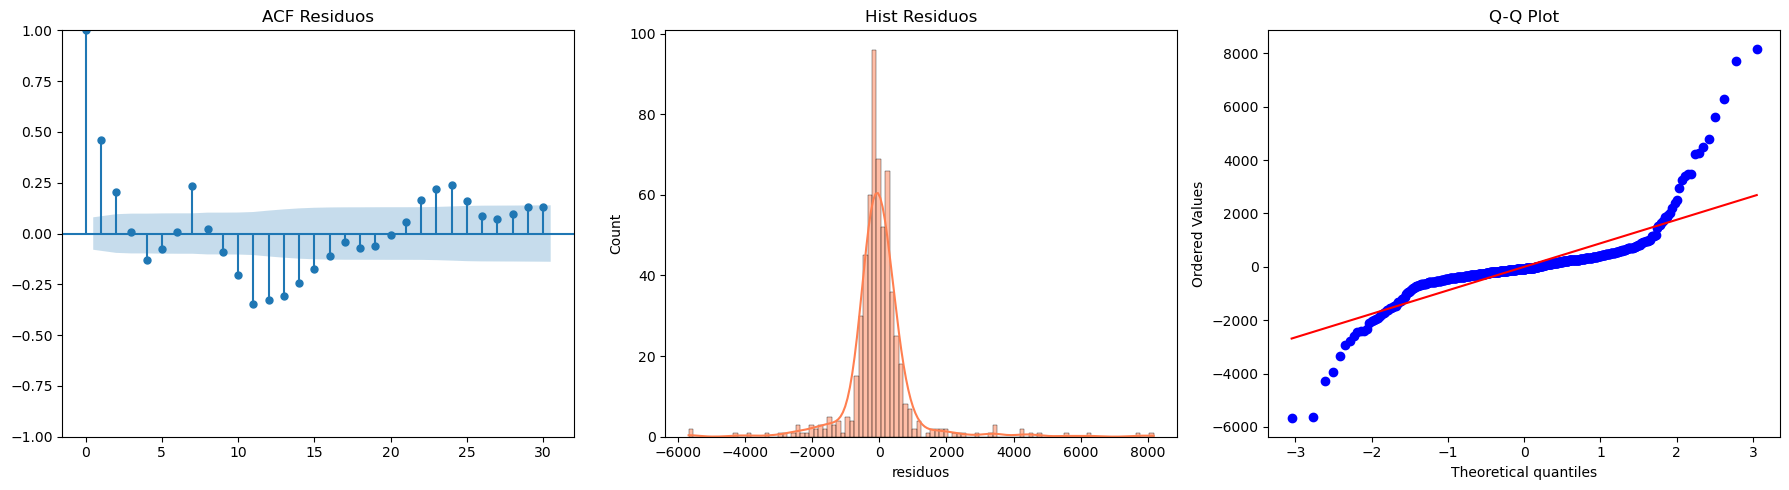

11:23:26 - cmdstanpy - INFO - Chain [1] start processing
11:23:26 - cmdstanpy - INFO - Chain [1] done processing
11:23:26 - cmdstanpy - INFO - Chain [1] start processing


VIF Variables Exógenas: {'precio_promedio': np.float64(1.0011533352608357), 'stock_actual': np.float64(1.001153335260881)}
Mitigación: Si VIF > 10 o el Q-Q Plot no es normal, XGBoost (arriba) absorbe esta no linealidad.
--- Sensibilidad al hiperparámetro (changepoint_prior_scale) ---
Flexibilidad 0.01 -> MAPE: 1330.58%


11:23:26 - cmdstanpy - INFO - Chain [1] done processing
11:23:26 - cmdstanpy - INFO - Chain [1] start processing
11:23:26 - cmdstanpy - INFO - Chain [1] done processing


Flexibilidad 0.05 -> MAPE: 698.52%
Flexibilidad 0.5 -> MAPE: 376.36%
\--- Feature Importance XGBoost ---
categoria: 0.3353
region: 0.1736
marca: 0.1729
stock_actual: 0.1482
precio_promedio: 0.1436
ciudad: 0.0260
tipo_y: 0.0003
Módulo de Insumo de Inventario cargado en memoria para proyectar GMROI.


In [15]:
# 7.1 Modelo Prophet para Validación
print("Entrenando Prophet...")
df_prophet = df_unificado.groupby('fecha').agg(y=('cantidad_vendida', 'sum'), precio_promedio=('precio_promedio', 'mean')).reset_index()
df_prophet.rename(columns={'fecha': 'ds'}, inplace=True)
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

m_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True)
m_prophet.add_regressor('precio_promedio')
m_prophet.fit(df_prophet)

forecast = m_prophet.predict(df_prophet)
df_prophet['prediccion'] = forecast['yhat']
df_prophet['residuos'] = df_prophet['y'] - df_prophet['prediccion']

# 7.2 Verificación de Supuestos (ACF, Q-Q, VIF)
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
plot_acf(df_prophet['residuos'].dropna(), ax=axs[0], lags=30)
axs[0].set_title('ACF Residuos')
sns.histplot(df_prophet['residuos'], kde=True, ax=axs[1], color='coral')
axs[1].set_title('Hist Residuos')
stats.probplot(df_prophet['residuos'].dropna(), dist="norm", plot=axs[2])
axs[2].set_title('Q-Q Plot')
plt.tight_layout()
plt.show()

# VIF
exogenas = df_unificado[['precio_promedio', 'stock_actual']].dropna()
vif = [variance_inflation_factor(exogenas.values, i) for i in range(len(exogenas.columns))]
print(f"VIF Variables Exógenas: {dict(zip(exogenas.columns, vif))}")
print("Mitigación: Si VIF > 10 o el Q-Q Plot no es normal, XGBoost (arriba) absorbe esta no linealidad.")

# 7.3 Sensibilidad (MAPE)
print("--- Sensibilidad al hiperparámetro (changepoint_prior_scale) ---")
for cps in [0.01, 0.05, 0.5]:
    m = Prophet(changepoint_prior_scale=cps).add_regressor('precio_promedio').fit(df_prophet)
    pred = m.predict(df_prophet)
    mask = df_prophet['y'] > 0
    mape = mean_absolute_percentage_error(df_prophet.loc[mask, 'y'], pred.loc[mask, 'yhat'])
    print(f"Flexibilidad {cps} -> MAPE: {mape*100:.2f}%")

# 7.4 Interpretabilidad
print("\--- Feature Importance XGBoost ---")
imp_dict = dict(zip(features, modelo_xgb.feature_importances_))
for k, v in sorted(imp_dict.items(), key=lambda item: item[1], reverse=True):
    print(f"{k}: {v:.4f}")

# 7.5 Insumo GMROI Histórico
inventario_promedio_historico = stock.groupby('id_producto')['cantidad'].mean().reset_index()
print("Módulo de Insumo de Inventario cargado en memoria para proyectar GMROI.")